#preprocessing

In [ ]:
# data load
!pip -q install opendatasets
from pathlib import Path
import opendatasets as od

RAW = Path("/content/data"); RAW.mkdir(parents=True, exist_ok=True)
od.download("https://www.kaggle.com/datasets/tushar5harma/plant-village-dataset-updated",
            data_dir=str(RAW/"plant_village_updated"))
print("Ready at:", RAW/"plant_village_updated")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: amalaseiri
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tushar5harma/plant-village-dataset-updated


100%|██████████| 1.00G/1.00G [00:10<00:00, 104MB/s] 



Ready at: /content/data/plant_village_updated


In [ ]:
#  Total number of images
from pathlib import Path
import os, shutil, re, numpy as np


ROOT = Path("/content/data/plant_village_updated")
assert ROOT.exists(), f"المجلد غير موجود: {ROOT}"


subdirs = [d for d in ROOT.iterdir() if d.is_dir()]
if len(subdirs) == 1 and not (ROOT/"train").exists():
    ROOT = subdirs[0]
print("Using dataset root:", ROOT)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def is_image(p: Path):
    return p.is_file() and p.suffix.lower() in IMG_EXTS

def clean_text(s: str):
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    return s

UNIFIED = ROOT.parent / (ROOT.name + "_unified")
if UNIFIED.exists():
    shutil.rmtree(UNIFIED)
for sp in ["train","val","test"]:
    (UNIFIED/sp).mkdir(parents=True, exist_ok=True)


SPLIT_ALIASES = {
    "train": ["train","Train","TRAIN","training","Training"],
    "val":   ["val","Val","valid","Valid","validation","Validation"],
    "test":  ["test","Test","TEST","testing","Testing"],
}

rng = np.random.default_rng(42)

def copy_images(src_files, dst_dir: Path):
    dst_dir.mkdir(parents=True, exist_ok=True)
    for img in src_files:
        tgt = dst_dir / img.name

        if tgt.exists():
            stem, suf = tgt.stem, tgt.suffix
            k = 1
            while (dst_dir / f"{stem}_{k}{suf}").exists():
                k += 1
            tgt = dst_dir / f"{stem}_{k}{suf}"
        shutil.copy2(img, tgt)


crops = [d for d in ROOT.iterdir() if d.is_dir()]
total_copied = 0
for crop in crops:
    crop_name = clean_text(crop.name)


    found_split = False
    split_dirs = {}
    for split_key, aliases in SPLIT_ALIASES.items():
        for name in aliases:
            cand = crop / name
            if cand.exists():
                split_dirs[split_key] = cand
                found_split = True
                break

    if found_split:

        for split_key, split_dir in split_dirs.items():
            for disease_dir in sorted([d for d in split_dir.iterdir() if d.is_dir()]):
                disease_name = clean_text(disease_dir.name)
                class_name = f"{crop_name} - {disease_name}"
                files = [p for p in disease_dir.rglob("*") if is_image(p)]
                copy_images(files, UNIFIED / split_key / class_name)
                total_copied += len(files)
    else:

        disease_dirs = [d for d in crop.iterdir() if d.is_dir()]
        for disease_dir in disease_dirs:
            disease_name = clean_text(disease_dir.name)
            class_name = f"{crop_name} - {disease_name}"
            files = [p for p in disease_dir.rglob("*") if is_image(p)]
            if not files:
                continue
            rng.shuffle(files)
            n = len(files)
            n_train = int(n * 0.70)
            n_val   = int(n * 0.15)
            n_test  = n - n_train - n_val
            splits = {
                "train": files[:n_train],
                "val"  : files[n_train:n_train+n_val],
                "test" : files[n_train+n_val:]
            }
            for split_key, group in splits.items():
                copy_images(group, UNIFIED / split_key / class_name)
            total_copied += n

print("Unified dataset built at:", UNIFIED)
print("Total copied images:", total_copied)


Using dataset root: /content/data/plant_village_updated/plant-village-dataset-updated
Unified dataset built at: /content/data/plant_village_updated/plant-village-dataset-updated_unified
Total copied images: 67118


In [ ]:
# مجموع عدد الصور في لكل من
# train,test,val


from collections import defaultdict
import pandas as pd


ROOT = None
for cand in [globals().get("DATA_DIR"), globals().get("UNIFIED")]:
    if cand is None:
        continue
    cand = Path(cand)
    if (cand/"train").exists():
        ROOT = cand
        break
assert ROOT is not None, "حددي ROOT: إما DATA_DIR (من resplit) أو UNIFIED (من التوحيد) ويحتوي مجلد train/."


IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS

def count_images_dir(d: Path) -> int:
    return sum(1 for p in d.rglob("*") if is_image(p))


splits = ["train","val"] + (["test"] if (ROOT/"test").exists() else [])


by_crop = defaultdict(list)
rows = []

train_class_dirs = sorted([d for d in (ROOT/"train").iterdir() if d.is_dir()], key=lambda x: x.name)

for d in train_class_dirs:
    name = d.name
    if " - " in name:
        crop_name, disease = name.split(" - ", 1)
    else:
        parts = name.split()
        crop_name, disease = parts[0], " ".join(parts[1:]) if len(parts)>1 else "(Unknown)"

    counts = {s: count_images_dir(ROOT/s/name) for s in splits}
    counts["total"] = sum(counts.values())

    by_crop[crop_name].append((disease, name, counts))
    rows.append({
        "crop": crop_name,
        "class_name": name,
        "disease": disease,
        **{s: counts[s] for s in splits},
        "total": counts["total"]
    })


print("\n📚 Classes by crop (with image counts):")
for crop_name in sorted(by_crop.keys()):
    items = sorted(by_crop[crop_name], key=lambda x: x[0])
    crop_tot = {s: sum(it[2][s] for it in items) for s in splits}
    crop_tot["total"] = sum(crop_tot.values())
    header = " | ".join([f"{s}={crop_tot[s]}" for s in splits] + [f"total={crop_tot['total']}"])
    print(f"\n{crop_name} ({len(items)} classes) [{header}]")
    for i, (dz, class_name, cnts) in enumerate(items, 1):
        line = " | ".join([f"{s}:{cnts[s]}" for s in splits] + [f"Σ:{cnts['total']}"])
        print(f"  {i:2d}. {dz} -> {line}")

# 6) حفظ CSV
df = pd.DataFrame(rows)
csv_path = ROOT / "class_counts_by_crop.csv"
df.to_csv(csv_path, index=False)
print("\n💾 Saved counts table to:", csv_path)

totals = {s: count_images_dir(ROOT/s) for s in splits}
grand_total = sum(totals.values())
print("\n📊 Totals (images per split):")
for s in splits:
    print(f"  {s:<5} = {totals[s]}")
print(f"  total = {grand_total}")



📚 Classes by crop (with image counts):

Apple (4 classes) [train=7771 | val=1747 | test=196 | total=9714]
   1. Apple Scab -> train:2016 | val:453 | test:51 | Σ:2520
   2. Black Rot -> train:1987 | val:447 | test:50 | Σ:2484
   3. Cedar Apple Rust -> train:1760 | val:396 | test:44 | Σ:2200
   4. Healthy -> train:2008 | val:451 | test:51 | Σ:2510

Bell Pepper (2 classes) [train=3901 | val=877 | test=98 | total=4876]
   1. Bacterial Spot -> train:1913 | val:430 | test:48 | Σ:2391
   2. Healthy -> train:1988 | val:447 | test:50 | Σ:2485

Cherry (2 classes) [train=3509 | val=788 | test=89 | total=4386]
   1. Healthy -> train:1826 | val:410 | test:46 | Σ:2282
   2. Powdery Mildew -> train:1683 | val:378 | test:43 | Σ:2104

Corn (Maize) (4 classes) [train=7316 | val=1645 | test=188 | total=9149]
   1. Cercospora Leaf Spot -> train:1642 | val:369 | test:45 | Σ:2056
   2. Common Rust -> train:1907 | val:429 | test:48 | Σ:2384
   3. Healthy -> train:1859 | val:418 | test:47 | Σ:2324
   4. Nort

In [ ]:


from pathlib import Path
import shutil, re
from collections import Counter
import pandas as pd


SRC = Path("/content/data/plant_village_updated/plant-village-dataset-updated")
DST = SRC.parent / (SRC.name + "_unified")
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
SPLITS = {"train","val","test"}

DST.mkdir(parents=True, exist_ok=True)

def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS

def clean(s: str) -> str:
    s = s.replace("_", " ")
    s = re.sub(r"[()]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def split_plant_disease(name: str):
    """
    يحاول فصل 'Plant - Disease' أو 'Plant Disease' الذكي.
    يعيد (plant, disease) لو قدر، وإلا يرجّع (None, None)
    """
    n = clean(name)


    if " - " in n:
        plant, disease = n.split(" - ", 1)
        return clean(plant), clean(disease)


    plants = [
        "Apple","Bell Pepper","Cherry","Corn (Maize)","Corn Maize","Grape",
        "Peach","Potato","Strawberry","Tomato"
    ]
    for plant in plants:
        if n.lower().startswith(plant.lower()):
            disease = clean(n[len(plant):])
            plant = "Corn (Maize)" if plant.lower() in {"corn maize","corn (maize)"} else plant
            return plant, disease

    return None, None

def iter_leaf_folders(base: Path):
    """
    يُرجع مجلّدات الأوراق التي تحوي صورًا، مع محاولة استخراج (plant, disease).
    يتعامل مع:
      - base/Plant/SPLIT/Disease
      - base/Plant/Disease
      - base/"Plant - Disease"
      - base/أي_بنية_قديمة لكن فيها صور مباشرة
    """
    for plant_dir in base.iterdir():
        if not plant_dir.is_dir():
            continue

        # 1) مجلد باسم "Plant - Disease"
        p_plant, p_dis = split_plant_disease(plant_dir.name)
        if p_plant and p_dis and any(is_image(x) for x in plant_dir.rglob("*")):
            yield (p_plant, p_dis, plant_dir)
            continue


        plant_name = clean(plant_dir.name)


        subdirs = [d for d in plant_dir.iterdir() if d.is_dir()]
        if not subdirs:

            if any(is_image(x) for x in plant_dir.iterdir()):
                yield (plant_name, "", plant_dir)
            continue


        split_dirs = [d for d in subdirs if d.name.lower() in SPLITS]
        if split_dirs:
            for sp in split_dirs:
                for disease_dir in [d for d in sp.iterdir() if d.is_dir()]:
                    if any(is_image(x) for x in disease_dir.iterdir()):
                        yield (plant_name, clean(disease_dir.name), disease_dir)
            continue


        for disease_dir in subdirs:
            if any(is_image(x) for x in disease_dir.iterdir()):

                pp, dd = split_plant_disease(disease_dir.name)
                if pp and dd:
                    yield (pp, dd, disease_dir)
                else:
                    yield (plant_name, clean(disease_dir.name), disease_dir)

def unique_copy(src: Path, dst_dir: Path):
    """
    نسخ مع تجنّب استبدال ملفات لها نفس الاسم: نضيف لاحقة رقمية إذا لزم.
    """
    dst_dir.mkdir(parents=True, exist_ok=True)
    name = src.name
    target = dst_dir / name
    if not target.exists():
        shutil.copy2(src, target)
        return target

    stem, suf = src.stem, src.suffix
    k = 1
    while True:
        cand = dst_dir / f"{stem}_{k}{suf}"
        if not cand.exists():
            shutil.copy2(src, cand)
            return cand
        k += 1


counts = Counter()
mappings = []
unmatched = []

for plant, disease, src_dir in iter_leaf_folders(SRC):

    plant = clean(plant) if plant else ""
    disease = clean(disease) if disease else "Healthy"
    dst_class = f"{plant} {disease}".strip()
    dst_class = re.sub(r"\s+", " ", dst_class)

    n_before = counts[dst_class]
    for p in src_dir.iterdir():
        if is_image(p):
            unique_copy(p, DST / dst_class)
            counts[dst_class] += 1

    n_new = counts[dst_class] - n_before
    mappings.append((plant, disease, str(src_dir), dst_class, n_new))


    if not plant or dst_class.lower() in {"", "healthy"}:
        unmatched.append((plant or "?", disease or "?", str(src_dir)))

print(f"✅ Unified dataset created at: {DST}")
print(f"🧩 Total classes: {len(counts)}")
print(f"📸 Total images: {sum(counts.values())}\n")

print("Classes & counts:")
for cls in sorted(counts):
    print(f"- {cls}: {counts[cls]}")


df = pd.DataFrame(mappings, columns=["plant","disease","src_dir","dst_class","copied_images"])
csv_path = DST / "unify_report.csv"
df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"\n📝 Saved mapping report: {csv_path}")

if unmatched:
    print("\n⚠️ Unmatched/weakly parsed entries (check and rerun if needed):")
    for plant, disease, src in unmatched[:30]:
        print(f"- plant='{plant}' disease='{disease}' from: {src}")
    if len(unmatched) > 30:
        print(f"... and {len(unmatched)-30} more")

✅ Unified dataset created at: /content/data/plant_village_updated/plant-village-dataset-updated_unified
🧩 Total classes: 29
📸 Total images: 67111

Classes & counts:
- Apple Apple Scab: 2520
- Apple Black Rot: 2484
- Apple Cedar Apple Rust: 2200
- Apple Healthy: 2510
- Bell Pepper Bacterial Spot: 2391
- Bell Pepper Healthy: 2485
- Cherry Healthy: 2282
- Cherry Powdery Mildew: 2104
- Corn Maize Cercospora Leaf Spot: 2052
- Corn Maize Common Rust: 2384
- Corn Maize Healthy: 2324
- Corn Maize Northern Leaf Blight: 2385
- Grape Black Rot: 2360
- Grape Esca Black Measles: 2400
- Grape Healthy: 2115
- Grape Leaf Blight: 2152
- Peach Bacterial Spot: 2297
- Peach Healthy: 2160
- Potato Early Blight: 2424
- Potato Healthy: 2280
- Potato Late Blight: 2424
- Strawberry Healthy: 2280
- Strawberry Leaf Scorch: 2218
- Tomato Bacterial Spot: 2127
- Tomato Early Blight: 2400
- Tomato Healthy: 2407
- Tomato Late Blight: 2314
- Tomato Septoria Leaf Spot: 2181
- Tomato Yellow Leaf Curl Virus: 2451

📝 Save

In [ ]:
# Remove Duplicates

!pip -q install imagehash
from pathlib import Path
from PIL import Image, ImageFile
import imagehash, pandas as pd, shutil, collections, os

ImageFile.LOAD_TRUNCATED_IMAGES = True
IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS


DATA_DIR = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified")
assert (DATA_DIR/"train").exists(), f"DATA_DIR غير موجود أو لا يحوي train: {DATA_DIR}"

REPORT_ONLY       = False
PREFER_SPLIT_KEEP = "train"

TRASH_DIR  = DATA_DIR.parent / (DATA_DIR.name + "_duplicates_trash")
REPORTS    = DATA_DIR / "_reports"
TRASH_DIR.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)


def phashes_in_split(split: str):
    base = DATA_DIR / split
    hmap = collections.defaultdict(list)
    if not base.exists():
        return hmap
    for p in base.rglob("*"):
        if not is_image(p):
            continue
        try:
            with Image.open(p) as im:
                im = im.convert("RGB")
                h = str(imagehash.phash(im))
            hmap[h].append(p)
        except Exception as e:

            pass
    return hmap

splits_present = [s for s in ["train","val","test"] if (DATA_DIR/s).exists()]
h_by_split     = {s: phashes_in_split(s) for s in splits_present}


dups_within_rows = []
for s in splits_present:
    for h, paths in h_by_split[s].items():
        if len(paths) > 1:
            for p in paths:
                dups_within_rows.append([s, h, str(p)])


h_sets = {s: set(h_by_split[s].keys()) for s in splits_present}
dups_across_rows, pairs = [], []
if "train" in h_sets and "val"  in h_sets: pairs.append(("train","val"))
if "train" in h_sets and "test" in h_sets: pairs.append(("train","test"))
if "val"   in h_sets and "test" in h_sets: pairs.append(("val","test"))

for a, b in pairs:
    inter = h_sets[a] & h_sets[b]
    for h in inter:
        for p in h_by_split[a][h]:
            dups_across_rows.append([a, b, h, str(p)])
        for p in h_by_split[b][h]:
            dups_across_rows.append([a, b, h, str(p)])


df_within = pd.DataFrame(dups_within_rows, columns=["split","phash","path"])
df_across = pd.DataFrame(dups_across_rows, columns=["split_a","split_b","phash","path"])
csv_within = REPORTS / "duplicates_within_split.csv"
csv_across = REPORTS / "duplicates_across_splits.csv"
if not df_within.empty: df_within.to_csv(csv_within, index=False)
if not df_across.empty: df_across.to_csv(csv_across, index=False)
print(f"داخل التقسيم (صفوف): {len(df_within)} | بين التقسيمات (صفوف): {len(df_across)}")
print("Saved:", (csv_within if not df_within.empty else "-"), "|",
               (csv_across if not df_across.empty else "-"))


def unique_in_trash(p: Path) -> Path:
    """أعطِ اسمًا غير مصطدم في TRASH_DIR مبنيًا على اسم الملف الأصلي"""
    stem, suf = p.stem, p.suffix
    dst = TRASH_DIR / (stem + suf)
    k = 1
    while dst.exists():
        dst = TRASH_DIR / f"{stem}_{k}{suf}"
        k += 1
    return dst

if not REPORT_ONLY:
    moved = 0

    for s in splits_present:
        for h, paths in h_by_split[s].items():
            if len(paths) > 1:
                for p in paths[1:]:
                    if p.exists():
                        shutil.move(str(p), str(unique_in_trash(p)))
                        moved += 1

    if PREFER_SPLIT_KEEP in h_sets:
        for other in [x for x in splits_present if x != PREFER_SPLIT_KEEP]:
            inter = h_sets[PREFER_SPLIT_KEEP] & h_sets[other]
            for h in inter:
                for p in h_by_split[other][h]:
                    if p.exists():
                        shutil.move(str(p), str(unique_in_trash(p)))
                        moved += 1
    print(f"🚛 moved {moved} duplicates -> {TRASH_DIR}")
else:
    print("Report-only: لم ننقل/نحذف أي ملف.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 12.7 MB/s eta 0:00:00
داخل التقسيم (صفوف): 226 | بين التقسيمات (صفوف): 102
Saved: /content/data/plant_village_updated/plant-village-dataset-updated_unified/_reports/duplicates_within_split.csv | /content/data/plant_village_updated/plant-village-dataset-updated_unified/_reports/duplicates_across_splits.csv
🚛 moved 165 duplicates -> /content/data/plant_village_updated/plant-village-dataset-updated_unified_duplicates_trash


In [ ]:
#التاكد من عدم وجود تكرارات
from pathlib import Path
import pandas as pd, os

root = DATA_DIR
trash = root.parent / (root.name + "_duplicates_trash")
print("TRASH_DIR =", trash)


!pip -q install imagehash >/dev/null
REPORT_ONLY = True

from torchvision.datasets import ImageFolder
from torchvision import transforms
val_classes = sorted([d.name for d in (root/"val").iterdir() if d.is_dir()])
test_classes = sorted([d.name for d in (root/"test").iterdir()]) if (root/"test").exists() else []

def count_images(dirpath):
    exts = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
    return sum(1 for p in Path(dirpath).rglob("*") if p.suffix.lower() in exts)

bad_val  = [c for c in val_classes  if count_images(root/"val"/c)==0]
bad_test = [c for c in test_classes if count_images(root/"test"/c)==0]

print("empty in val :", len(bad_val))
print("empty in test:", len(bad_test))
if bad_val:  print(" ->", bad_val[:10], "...")
if bad_test: print(" ->", bad_test[:10], "...")

TRASH_DIR = /content/data/plant_village_updated/plant-village-dataset-updated_unified_duplicates_trash
empty in val : 0
empty in test: 0


In [ ]:

import shutil, os
if os.path.isdir(trash):
    shutil.rmtree(trash)
    print("Deleted:", trash)
else:
    print(" No trash folder:", trash)

Deleted: /content/data/plant_village_updated/plant-village-dataset-updated_unified_duplicates_trash


In [ ]:
# Partitioning


from pathlib import Path
import numpy as np, shutil

OLD = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified")
assert (OLD/"train").exists(), "تأكدي من مسار مجلد *_unified"

R_TRAIN, R_VAL = 0.70, 0.15
R_TEST = 1.0 - R_TRAIN - R_VAL   # = 0.15
SEED = 42

NEW = OLD.parent / (OLD.name + "_resplit_70_15_15")
if NEW.exists(): shutil.rmtree(NEW)
for sp in ["train","val","test"]:
    (NEW/sp).mkdir(parents=True, exist_ok=True)

IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_img(p): return p.is_file() and p.suffix.lower() in IMG_EXTS

def all_classes(root: Path):
    names=set()
    for sp in ["train","val","test"]:
        d=root/sp
        if d.exists(): names |= {x.name for x in d.iterdir() if x.is_dir()}
    return sorted(names)

def all_images_of_class(root: Path, cls: str):
    files=[]
    for sp in ["train","val","test"]:
        d=root/sp/cls
        if d.exists(): files += [p for p in d.rglob("*") if is_img(p)]
    return files

rng = np.random.default_rng(SEED)
totals = {"train":0,"val":0,"test":0}
classes = all_classes(OLD)

for cls in classes:
    files = all_images_of_class(OLD, cls)
    n = len(files)
    if n == 0:
        continue
    rng.shuffle(files)


    n_tr = int(round(n * R_TRAIN))
    n_va = int(round(n * R_VAL))
    n_te = n - n_tr - n_va


    if n >= 3:
        if n_tr == 0: n_tr = 1
        if n_va == 0: n_va = 1
        if n_te == 0: n_te = 1
        while n_tr + n_va + n_te > n:
            if   n_tr >= n_va and n_tr >= n_te: n_tr -= 1
            elif n_va >= n_tr and n_va >= n_te: n_va -= 1
            else: n_te -= 1
    elif n == 2:
        n_tr, n_va, n_te = 1, 1, 0
    else:  # n == 1
        n_tr, n_va, n_te = 1, 0, 0

    splits = {"train": files[:n_tr], "val": files[n_tr:n_tr+n_va], "test": files[n_tr+n_va:]}

    for sp, group in splits.items():
        out = NEW/sp/cls; out.mkdir(parents=True, exist_ok=True)
        for src in group:
            dst = out/src.name
            k=1
            while dst.exists():
                dst = out/f"{src.stem}_{k}{src.suffix}"; k+=1
            shutil.copy2(src, dst)
        totals[sp] += len(group)

print("✅ Resplit done at:", NEW)
print("📊 Totals:", totals, "| sum =", sum(totals.values()))


DATA_DIR = NEW


def count_images_dir(d: Path):
    return sum(1 for p in d.rglob("*") if is_img(p))

splits = ["train","val","test"]
totals2 = {s: count_images_dir(DATA_DIR/s) for s in splits}
print("\n📊 Totals (images per split):")
for s in splits: print(f"  {s:<5} = {totals2[s]}")
print("  total =", sum(totals2.values()))


✅ Resplit done at: /content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15
📊 Totals: {'train': 46868, 'val': 10047, 'test': 10038} | sum = 66953

📊 Totals (images per split):
  train = 46868
  val   = 10047
  test  = 10038
  total = 66953


In [ ]:

from pathlib import Path
import shutil

BASE = Path("/content/data/plant_village_updated")

OLD = BASE/"plant-village-dataset-updated_unified"
NEW = BASE/"plant-village-dataset-updated_unified_resplit_70_15_15"
ARCHIVE_DIR = BASE/"_archived_splits"
ARCHIVE_DIR.mkdir(exist_ok=True)


if OLD.exists():
    target = ARCHIVE_DIR/OLD.name
    if target.exists():
        shutil.rmtree(target)
    shutil.move(str(OLD), str(target))
    print("✅ moved OLD split to:", target)
else:
    print("ℹ️ OLD split not found:", OLD)


assert NEW.exists(), f"NEW split not found: {NEW}"
DATA_DIR = NEW
print("✅ Using DATA_DIR =", DATA_DIR)

IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
def is_img(p): return p.is_file() and p.suffix.lower() in IMG_EXTS
def count_images_dir(d):
    return sum(1 for p in d.rglob("*") if is_img(p))
#__________________________________________________________________________
splits = ["train","val"] + (["test"] if (DATA_DIR/"test").exists() else [])
totals = {s: count_images_dir(DATA_DIR/s) for s in splits}
print("\n📊 Totals (images per split) — should reflect only ONE split now:")
for s in splits: print(f"  {s:<5} = {totals[s]}")
print("  total =", sum(totals.values()))


✅ moved OLD split to: /content/data/plant_village_updated/_archived_splits/plant-village-dataset-updated_unified
✅ Using DATA_DIR = /content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15

📊 Totals (images per split) — should reflect only ONE split now:
  train = 46868
  val   = 10047
  test  = 10038
  total = 66953


In [ ]:

DATA_DIR = BASE/"plant-village-dataset-updated_unified_resplit_70_15_15"


In [ ]:
#Transform (resize, Orientation, Normalization)
from pathlib import Path
import torch
from PIL import ImageOps
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader



DATA_DIR = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15")
assert (DATA_DIR/"train").exists() and (DATA_DIR/"val").exists()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


IMG_SIZE = 299
BATCH = 32
NUM_WORKERS = 2

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Orientation + Resize(+crop) + Augment + Normalize
train_tfms = transforms.Compose([
    transforms.Lambda(lambda img: ImageOps.exif_transpose(img)),
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


eval_tfms = transforms.Compose([
    transforms.Lambda(lambda img: ImageOps.exif_transpose(img)),
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = ImageFolder(DATA_DIR/"train", transform=train_tfms)
val_ds   = ImageFolder(DATA_DIR/"val",   transform=eval_tfms)
test_ds  = ImageFolder(DATA_DIR/"test",  transform=eval_tfms) if (DATA_DIR/"test").exists() else None
assert train_ds.classes == val_ds.classes

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0))
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0))

xb, yb = next(iter(train_loader))
print("after normalize:", xb.shape, xb.dtype, "min:", float(xb.min()), "max:", float(xb.max()))


after normalize: torch.Size([32, 3, 299, 299]) torch.float32 min: -2.1179039478302 max: 2.640000104904175


#Building model(name of model)

In [ ]:

import torch, torch.nn as nn
from torchvision.models import inception_v3, Inception_V3_Weights
from pathlib import Path
import time
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = len(train_ds.classes)


weights = Inception_V3_Weights.IMAGENET1K_V1
model = inception_v3(weights=weights, aux_logits=True)

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
if getattr(model, "AuxLogits", None) is not None and hasattr(model.AuxLogits, "fc"):
    model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, NUM_CLASSES)

model = model.to(DEVICE)
print(f"✅ InceptionV3 ready | classes: {NUM_CLASSES} | device:", DEVICE)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 185MB/s] 


✅ InceptionV3 ready | classes: 29 | device: cuda


In [ ]:

from pathlib import Path
import time
import torch.optim as optim

OUT_DIR   = Path("./out"); OUT_DIR.mkdir(parents=True, exist_ok=True)
BEST_PATH = OUT_DIR / "googlenetv3_best.pt"

criterion_main = nn.CrossEntropyLoss(label_smoothing=0.0).to(DEVICE)
criterion_aux  = nn.CrossEntropyLoss(label_smoothing=0.0).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-5)

EPOCHS, PATIENCE, MIN_DELTA = 30, 4, 5e-4
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


def split_outputs(out):
    if hasattr(out, "logits"):
        return out.logits, getattr(out, "aux_logits", None), None
    if isinstance(out, (tuple, list)):
        if len(out) == 3:
            main, aux2, aux1 = out
            return main, aux1, aux2
        if len(out) == 2:
            main, aux = out
            return main, aux, None
    return out, None, None


def train_one_epoch():
    model.train()
    tot, correct, run = 0, 0, 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            out = model(xb)
            logits, aux1, aux2 = split_outputs(out)
            loss = criterion_main(logits, yb)
            if aux1 is not None: loss += 0.3 * criterion_aux(aux1, yb)
            if aux2 is not None: loss += 0.3 * criterion_aux(aux2, yb)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()

        run += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        tot += yb.size(0)

    scheduler.step()
    return run/tot, correct/tot


@torch.no_grad()
def evaluate(loader):
    model.eval()
    tot, correct, run = 0, 0, 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        out = model(xb)
        logits, _, _ = split_outputs(out)
        loss = criterion_main(logits, yb)
        run += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        tot += yb.size(0)
    return run/tot, correct/tot

#  Early Stopping
best_val_loss, wait = float("inf"), 0
history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}


SAVE_IMG_SIZE = IMG_SIZE
SAVE_TAG = "GOOGLENET_IMAGENET1K_V1"

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch()
    val_loss, val_acc = evaluate(val_loader)
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss);  history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} | "
          f"time={(time.time()-t0):.1f}s")

    if val_loss < (best_val_loss - MIN_DELTA):
        best_val_loss = val_loss
        torch.save({
            "model_state": model.state_dict(),
            "classes": train_ds.classes,
            "val_loss": best_val_loss,
            "img_size": SAVE_IMG_SIZE,
            "weights_tag": SAVE_TAG,
        }, BEST_PATH)
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping on val_loss (best={best_val_loss:.4f}).")
            break

print(f"\n✅ Best val_loss = {best_val_loss:.4f} | Saved -> {BEST_PATH}")


/tmp/ipython-input-3802994902.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipython-input-3802994902.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 01/30 | train_loss=0.4095 acc=0.8998 | val_loss=0.2834 acc=0.9110 | time=755.6s
Epoch 02/30 | train_loss=0.1679 acc=0.9568 | val_loss=0.0957 acc=0.9693 | time=737.6s
Epoch 03/30 | train_loss=0.1279 acc=0.9680 | val_loss=0.1036 acc=0.9664 | time=731.3s
Epoch 04/30 | train_loss=0.0859 acc=0.9782 | val_loss=0.0343 acc=0.9898 | time=733.4s
Epoch 05/30 | train_loss=0.0595 acc=0.9848 | val_loss=0.0219 acc=0.9922 | time=733.7s
Epoch 06/30 | train_loss=0.0426 acc=0.9889 | val_loss=0.0190 acc=0.9940 | time=730.9s
Epoch 07/30 | train_loss=0.0289 acc=0.9923 | val_loss=0.0142 acc=0.9955 | time=730.1s
Epoch 08/30 | train_loss=0.0152 acc=0.9962 | val_loss=0.0064 acc=0.9977 | time=722.1s
Epoch 09/30 | train_loss=0.0093 acc=0.9975 | val_loss=0.0050 acc=0.9983 | time=723.4s
Epoch 10/30 | train_loss=0.0055 acc=0.9986 | val_loss=0.0042 acc=0.9987 | time=726.9s
Epoch 11/30 | train_loss=0.0043 acc=0.9988 | val_loss=0.0043 acc=0.9987 | time=727.8s
Epoch 12/30 | train_loss=0.0044 acc=0.9987 | val_loss=

In [ ]:

import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt = torch.load(BEST_PATH, map_location=DEVICE)
state_dict = ckpt["model_state"]
classes = ckpt.get("classes", train_ds.classes)


model = models.inception_v3(aux_logits=True)

num_classes = len(classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
if model.AuxLogits is not None:
    model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)

model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        out = model(xb)


        if isinstance(out, (tuple, list)):
            logits = out[0]
        elif hasattr(out, "logits"):
            logits = out.logits
        else:
            logits = out

        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(yb.cpu().tolist())

print("\n" + "="*50)
print("             Final Classification Report")
print("="*50 + "\n")
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix shape:", cm.shape)



/usr/local/lib/python3.12/dist-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(



             Final Classification Report

                                     precision    recall  f1-score   support

                 Apple - Apple Scab     0.7377    0.9524    0.8314       378
                  Apple - Black Rot     0.6059    0.9973    0.7538       373
           Apple - Cedar Apple Rust     1.0000    0.2515    0.4020       326
                    Apple - Healthy     0.7558    0.9493    0.8416       375
       Bell Pepper - Bacterial Spot     0.9646    0.9861    0.9752       359
              Bell Pepper - Healthy     0.9681    0.9759    0.9720       373
                   Cherry - Healthy     1.0000    0.7778    0.8750       342
            Cherry - Powdery Mildew     0.9647    0.9525    0.9586       316
Corn (Maize) - Cercospora Leaf Spot     0.8991    0.9838    0.9395       308
         Corn (Maize) - Common Rust     0.9972    0.9972    0.9972       358
             Corn (Maize) - Healthy     1.0000    1.0000    1.0000       348
Corn (Maize) - Northern Leaf Bli

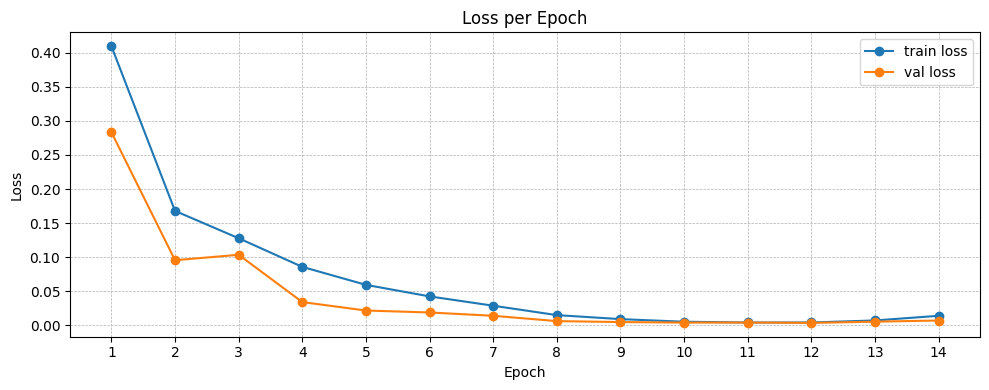

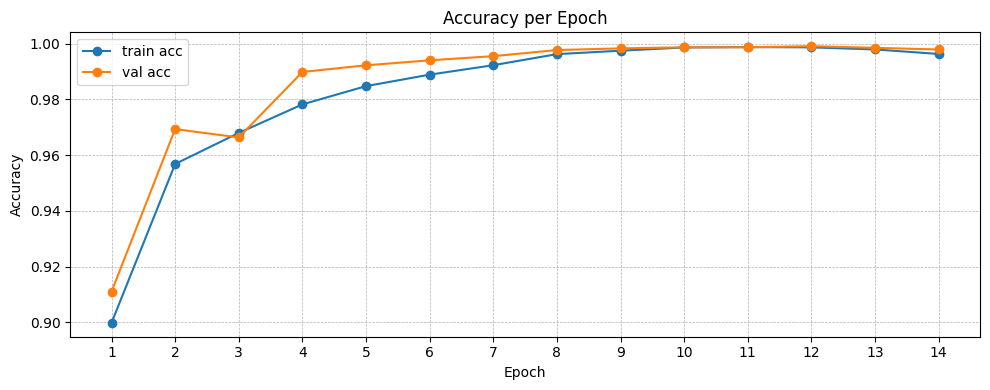

Saved: out/learning_curve_loss.png
Saved: out/learning_curve_acc.png


In [ ]:
#learnig curve
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


def plot_learning_curves(history, out_dir: Path = OUT_DIR, fname_prefix="learning_curve"):
    """
    history: dict يحتوي المفاتيح ['train_loss','val_loss','train_acc','val_acc']
    out_dir: مسار حفظ الصورة
    """
    out_dir.mkdir(parents=True, exist_ok=True)

    epochs = range(1, len(history["train_loss"]) + 1)


    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history["train_loss"], marker='o', label="train loss")
    plt.plot(epochs, history["val_loss"], marker='o', label="val loss")
    plt.title("Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(epochs)
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    loss_path = out_dir / f"{fname_prefix}_loss.png"
    plt.savefig(loss_path, dpi=150)
    plt.show()


    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history["train_acc"], marker='o', label="train acc")
    plt.plot(epochs, history["val_acc"], marker='o', label="val acc")
    plt.title("Accuracy per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.xticks(epochs)
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    acc_path = out_dir / f"{fname_prefix}_acc.png"
    plt.savefig(acc_path, dpi=150)
    plt.show()

    print(f"Saved: {loss_path}")
    print(f"Saved: {acc_path}")


plot_learning_curves(history)


/usr/local/lib/python3.12/dist-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


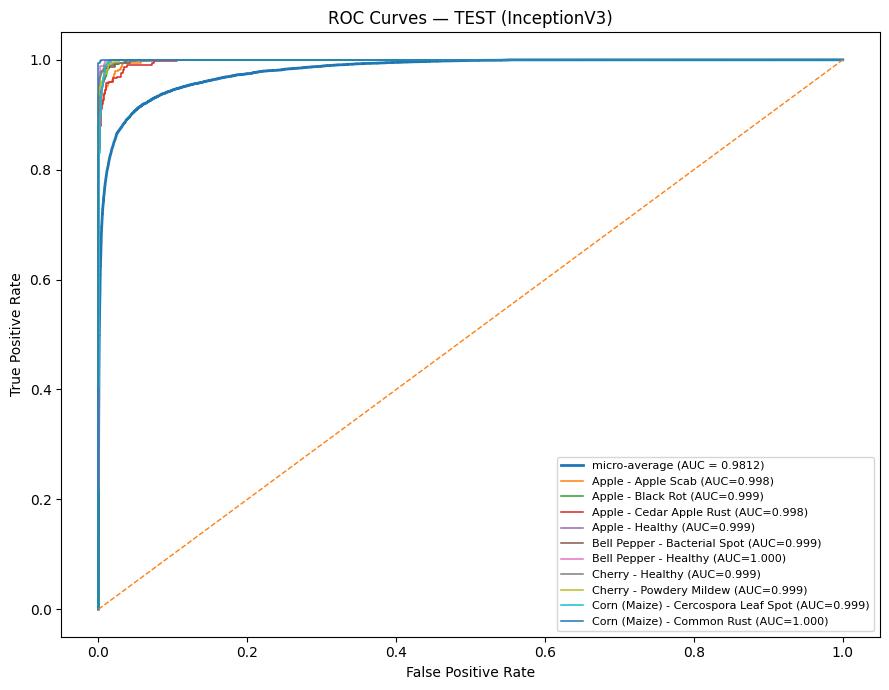

In [ ]:
# ===== ROC for InceptionV3 model =====
import numpy as np
from pathlib import Path
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


DATA_ROOT = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15")
TEST_DIR  = DATA_ROOT / "/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15/test"
CKPT      = Path("/content/out/googlenetv3_best.pt")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


ckpt = torch.load(CKPT, map_location=DEVICE)
classes = ckpt.get("classes", None)
if classes is None:
    raise ValueError("⚠️ checkpoint ما فيه 'classes'")

C = len(classes)
IMG_SIZE = ckpt.get("img_size", 224)


test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])


test_ds = datasets.ImageFolder(TEST_DIR, transform=test_tfms)
test_dl = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
class_names = test_ds.classes


model = models.inception_v3(aux_logits=True)
model.fc = nn.Linear(model.fc.in_features, C)
if model.AuxLogits is not None:
    model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, C)

model.load_state_dict(ckpt["model_state"])
model.to(DEVICE)
model.eval()


all_probs, all_targets = [], []
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(DEVICE)
        out = model(x)


        if isinstance(out, (tuple, list)):
            logits = out[0]
        elif hasattr(out, "logits"):
            logits = out.logits
        else:
            logits = out

        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_targets.append(y.numpy())

y_score = np.concatenate(all_probs, axis=0)
y_true  = np.concatenate(all_targets, axis=0)

# ROC
if C == 2:
    fpr, tpr, _ = roc_curve(y_true, y_score[:, 1])
    auc_val = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc_val:.4f}")
    plt.plot([0,1], [0,1], "--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — TEST (InceptionV3)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:

    y_true_bin = label_binarize(y_true, classes=list(range(C)))
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(C):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])


    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.figure(figsize=(9,7))
    plt.plot(fpr["micro"], tpr["micro"], lw=2,
             label=f"micro-average (AUC = {roc_auc['micro']:.4f})")


    max_to_plot = min(C, 10)
    for i in range(max_to_plot):
        plt.plot(fpr[i], tpr[i], lw=1.1,
                 label=f"{class_names[i]} (AUC={roc_auc[i]:.3f})")

    plt.plot([0,1], [0,1], "--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves — TEST (InceptionV3)")
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()



In [ ]:
# ===== Final Classification Report on TEST =====
from pathlib import Path
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TEST_DIR = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15/test")
BEST_PATH = Path("./out/googlenetv3_best.pt")
IMG_SIZE, BATCH_SIZE = 224, 64


test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# DataLoader test
test_ds = datasets.ImageFolder(TEST_DIR, transform=test_tfms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
num_classes = len(test_ds.classes)

try:
    model
    if hasattr(model, "fc") and getattr(model.fc, "out_features", None) != num_classes:
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        if hasattr(model, "aux1") and hasattr(model.aux1, "fc2"):
            model.aux1.fc2 = nn.Linear(model.aux1.fc2.in_features, num_classes)
        if hasattr(model, "aux2") and hasattr(model.aux2, "fc2"):
            model.aux2.fc2 = nn.Linear(model.aux2.fc2.in_features, num_classes)
except NameError:
    if "num_classes" in models.googlenet.__code__.co_varnames:
        model = models.googlenet(weights=None, aux_logits=True, num_classes=num_classes)
    else:
        model = models.googlenet(weights=None, aux_logits=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        if hasattr(model, "aux1") and hasattr(model.aux1, "fc2"):
            model.aux1.fc2 = nn.Linear(model.aux1.fc2.in_features, num_classes)
        if hasattr(model, "aux2") and hasattr(model.aux2, "fc2"):
            model.aux2.fc2 = nn.Linear(model.aux2.fc2.in_features, num_classes)


ckpt = torch.load(BEST_PATH, map_location=DEVICE)
sd = ckpt.get("model_state") or ckpt.get("model_state_dict") or ckpt.get("state_dict") or ckpt
sd = { (k[7:] if k.startswith("module.") else k): v for k,v in sd.items() }
_ = model.load_state_dict(sd, strict=False)
model.to(DEVICE).eval()


all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        out = model(xb)
        logits = out[0] if isinstance(out, (tuple, list)) else out
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(yb.cpu().tolist())

print("\n===== Final Classification Report — TEST =====\n")
print(classification_report(all_labels, all_preds, target_names=test_ds.classes, digits=4))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix shape:", cm.shape)



===== Final Classification Report — TEST =====

                                     precision    recall  f1-score   support

                 Apple - Apple Scab     0.7687    0.9233    0.8389       378
                  Apple - Black Rot     0.5196    1.0000    0.6838       372
           Apple - Cedar Apple Rust     1.0000    0.2883    0.4476       326
                    Apple - Healthy     0.8321    0.8853    0.8579       375
       Bell Pepper - Bacterial Spot     0.8452    0.9609    0.8993       358
              Bell Pepper - Healthy     0.9102    0.9812    0.9444       372
                   Cherry - Healthy     0.9965    0.8309    0.9062       343
            Cherry - Powdery Mildew     0.9797    0.9206    0.9493       315
Corn (Maize) - Cercospora Leaf Spot     0.8029    0.9123    0.8541       308
         Corn (Maize) - Common Rust     0.9725    0.9916    0.9820       357
             Corn (Maize) - Healthy     1.0000    0.9914    0.9957       349
Corn (Maize) - Northern Le

ℹ️ ckpt info -> img_size=299, tag=GOOGLENET_IMAGENET1K_V1


/usr/local/lib/python3.12/dist-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


✅ detected arch: inception_v3 | IMG_SIZE=299
ℹ️ Missing keys: 0 | Unexpected keys: 0


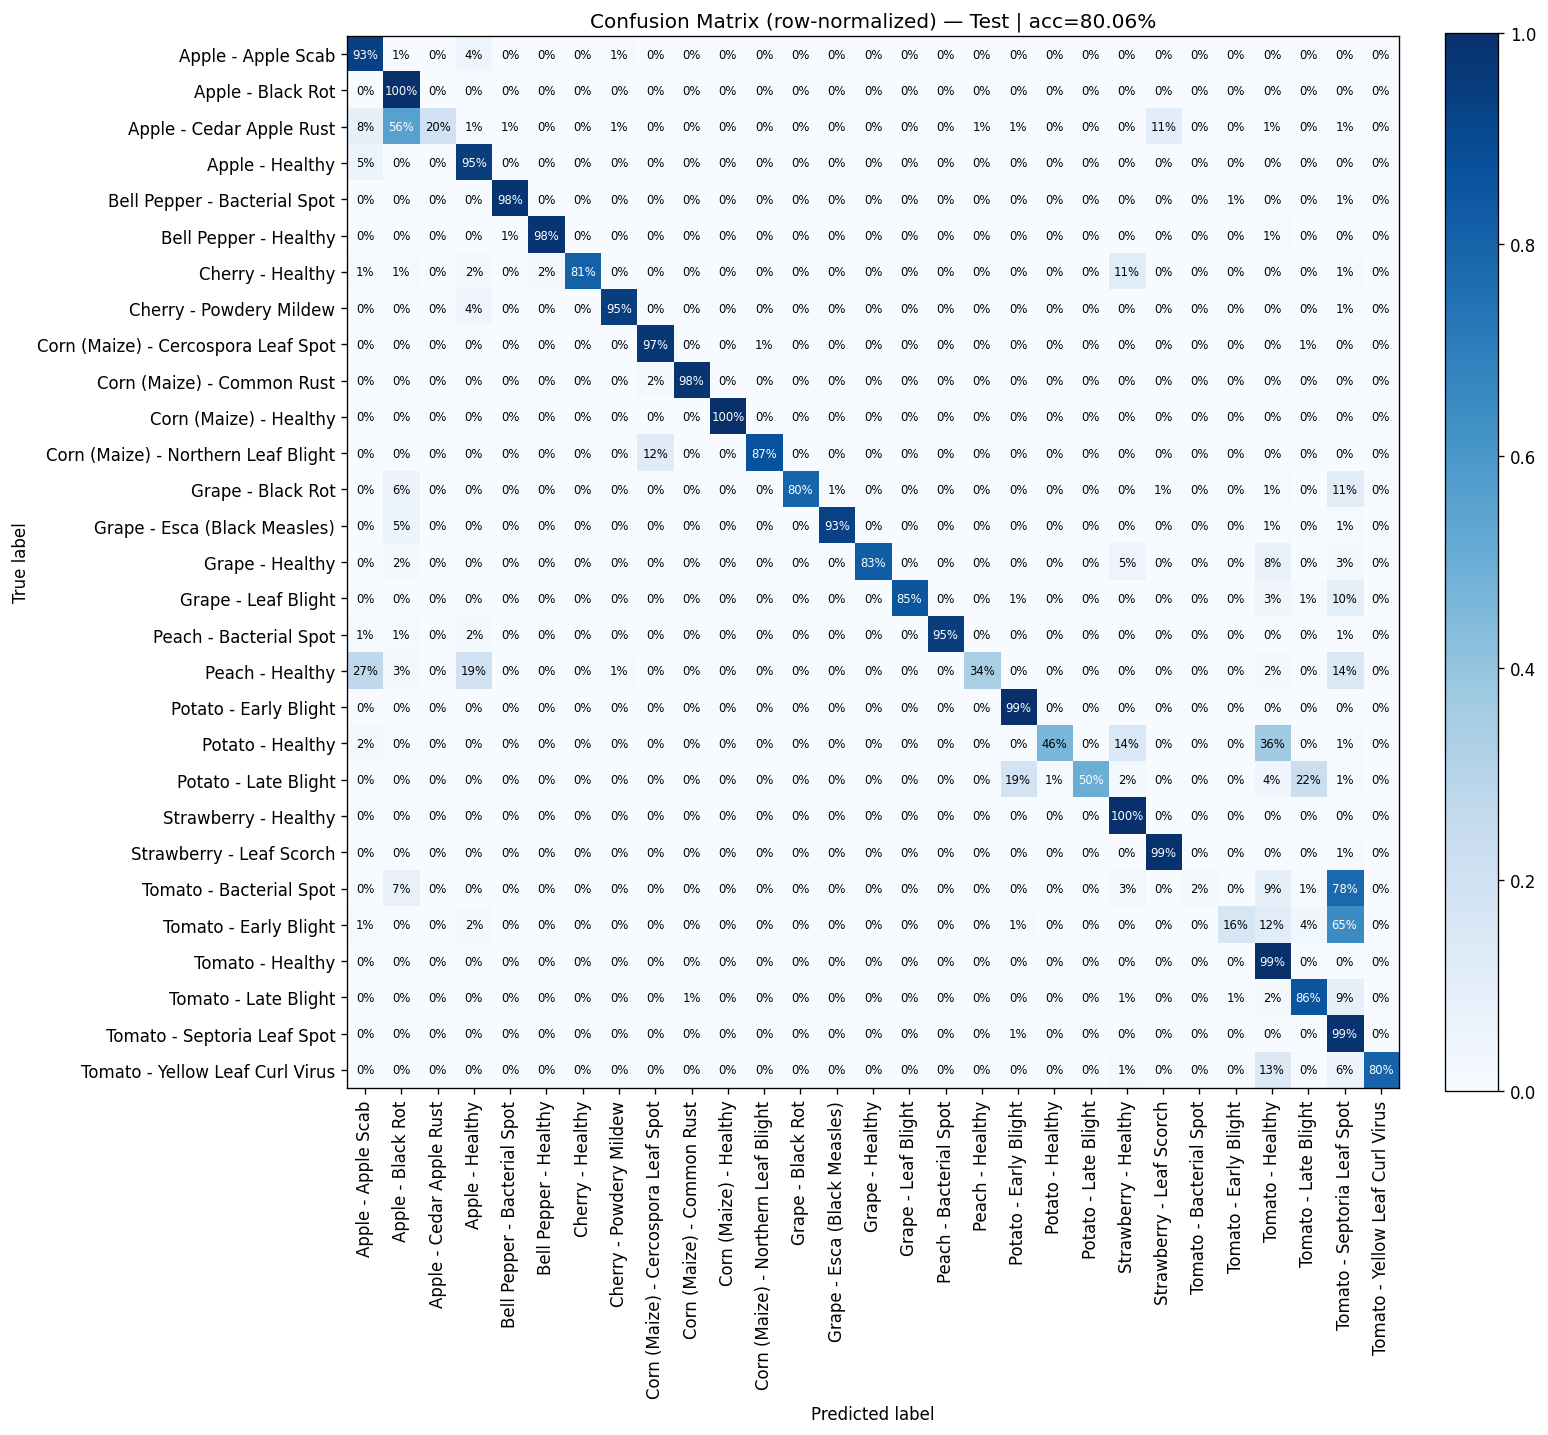


Overall accuracy: 80.06%

Per-class precision / recall / F1:

                                     precision    recall  f1-score   support

                 Apple - Apple Scab      0.695     0.934     0.797       378
                  Apple - Black Rot      0.579     0.997     0.732       372
           Apple - Cedar Apple Rust      1.000     0.199     0.332       326
                    Apple - Healthy      0.747     0.947     0.835       375
       Bell Pepper - Bacterial Spot      0.980     0.980     0.980       358
              Bell Pepper - Healthy      0.968     0.978     0.973       372
                   Cherry - Healthy      1.000     0.810     0.895       343
            Cherry - Powdery Mildew      0.961     0.946     0.954       315
Corn (Maize) - Cercospora Leaf Spot      0.854     0.971     0.909       308
         Corn (Maize) - Common Rust      0.991     0.978     0.984       357
             Corn (Maize) - Healthy      1.000     1.000     1.000       349
Corn (Maize)

In [ ]:

# 📊 Confusion Matrix

!pip -q install torch torchvision scikit-learn matplotlib

import torch, torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

DATA_TEST  = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15/test")
CKPT_PATH  = Path("/content/out/googlenetv3_best.pt")
assert DATA_TEST.exists(), f"❌ test غير موجود: {DATA_TEST}"
assert CKPT_PATH.exists(), f"❌ الملف غير موجود: {CKPT_PATH}"


ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)


ckpt_classes   = ckpt.get("classes", None)
ckpt_img_size  = int(ckpt.get("img_size", 224))
ckpt_tag       = str(ckpt.get("weights_tag", ""))
print(f"ℹ️ ckpt info -> img_size={ckpt_img_size}, tag={ckpt_tag}")

test_tfms = transforms.Compose([
    transforms.Resize(256 if ckpt_img_size == 224 else 342),
    transforms.CenterCrop(ckpt_img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

test_set = datasets.ImageFolder(str(DATA_TEST), transform=test_tfms)
class_names = ckpt_classes if ckpt_classes is not None else test_set.classes
NUM_CLASSES = len(class_names)
assert len(class_names) == NUM_CLASSES, f"❌ class_names={len(class_names)} != NUM_CLASSES={NUM_CLASSES}"

test_loader = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)



if isinstance(ckpt, dict) and "model_state" in ckpt and isinstance(ckpt["model_state"], dict):
    state = ckpt["model_state"]
elif isinstance(ckpt, dict) and "state_dict" in ckpt and isinstance(ckpt["state_dict"], dict):
    state = ckpt["state_dict"]
else:
    state = ckpt if isinstance(ckpt, dict) else None
if state is None:
    raise RuntimeError("❌ لم أجد state_dict داخل الملف.")


state = {k.replace("module.", ""): v for k, v in state.items()}


in_feat = None
for k, v in state.items():
    if k.endswith("fc.weight") and hasattr(v, "shape"):
        in_feat = int(v.shape[1])
        break

if in_feat == 2048 or ckpt_img_size == 299:
    arch = "inception_v3"
    IMG_SIZE = 299
    model = models.inception_v3(weights=None, aux_logits=True, num_classes=NUM_CLASSES)
else:
    arch = "googlenet"
    IMG_SIZE = 224
    model = models.googlenet(weights=None, aux_logits=True, num_classes=NUM_CLASSES)

print(f"✅ detected arch: {arch} | IMG_SIZE={IMG_SIZE}")


missing, unexpected = model.load_state_dict(state, strict=False)
print("ℹ️ Missing keys:", len(missing), "| Unexpected keys:", len(unexpected))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()


y_true, y_pred = [], []

@torch.no_grad()
def predict_batch(x):
    out = model(x)

    if hasattr(out, "logits"):
        out = out.logits
    elif isinstance(out, (tuple, list)):
        out = out[0]
    return out

for xb, yb in test_loader:
    xb = xb.to(device, non_blocking=True)
    logits = predict_batch(xb)
    preds = logits.argmax(dim=1).cpu().numpy()
    y_pred.extend(preds.tolist())
    y_true.extend(yb.numpy().tolist())

y_true = np.array(y_true); y_pred = np.array(y_pred)


cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(13, 13), dpi=120)
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set(
    xticks=np.arange(NUM_CLASSES),
    yticks=np.arange(NUM_CLASSES),
    xticklabels=class_names,
    yticklabels=class_names,
    ylabel='True label',
    xlabel='Predicted label',
    title=f'Confusion Matrix (row-normalized) — Test | acc={accuracy_score(y_true,y_pred)*100:.2f}%'
)
plt.setp(ax.get_xticklabels(), rotation=90, ha="center")


thresh = cm_norm.max() / 2.0
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        val = cm_norm[i, j] * 100.0
        txt = f"{val:.0f}%" if cm.sum(axis=1)[i] > 0 else "-"
        ax.text(j, i, txt, ha="center", va="center",
                color="white" if cm_norm[i, j] > thresh else "black", fontsize=7)

plt.tight_layout()
plt.show()


print("\nOverall accuracy:", f"{accuracy_score(y_true, y_pred)*100:.2f}%")
print("\nPer-class precision / recall / F1:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))


Path("reports").mkdir(exist_ok=True)
out_png = Path("reports/confusion_matrix_test.png")
fig.savefig(out_png, bbox_inches="tight")
print(f"\n✅ حُفظت صورة الكونفيوجن في: {out_png}")


✅ detected arch: googlenet | IMG_SIZE=224
Classes (29): ['Apple - Apple Scab', 'Apple - Black Rot', 'Apple - Cedar Apple Rust', 'Apple - Healthy', 'Bell Pepper - Bacterial Spot'] ... | صور test: 10038
ℹ️ Missing keys: 304 | Unexpected keys: 576 | Skipped (head): 3
✅ تم جمع 10038 تنبؤًا من TEST.


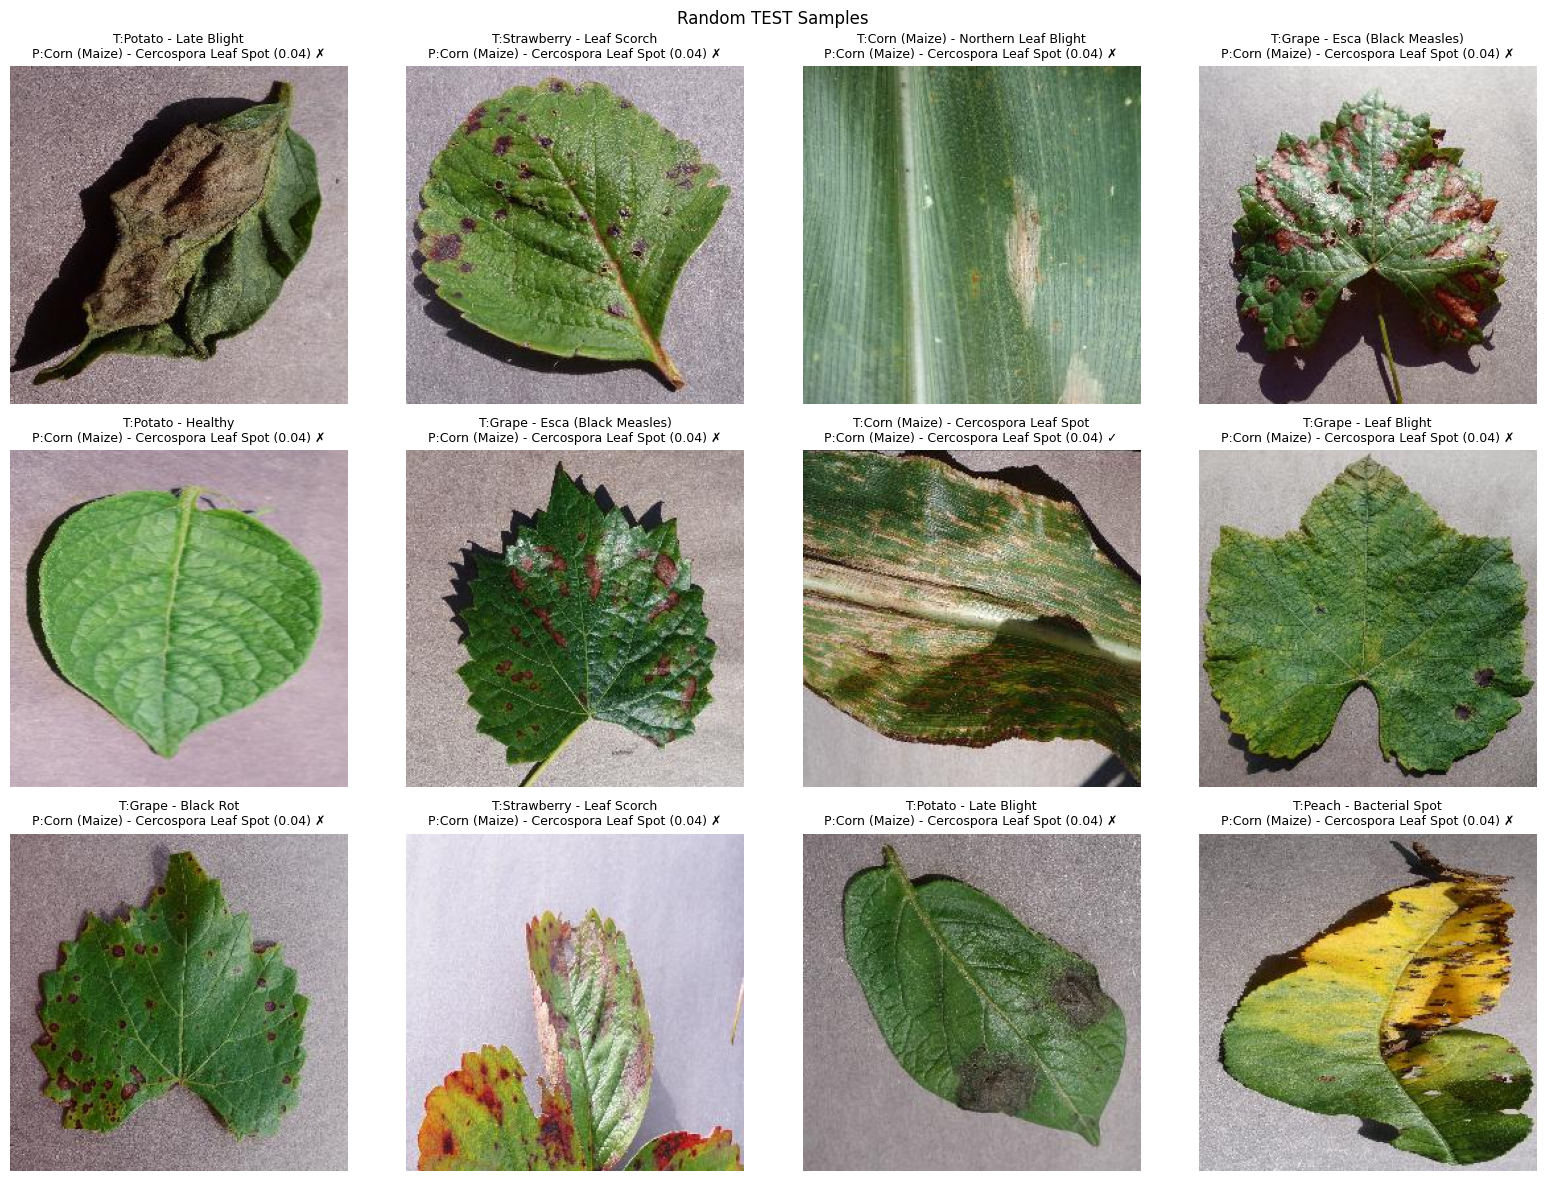

In [ ]:

from pathlib import Path
import math, re, random
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from PIL import Image


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TEST_DIR  = Path("/content/data/plant_village_updated/plant-village-dataset-updated_unified_resplit_70_15_15/test")
BEST_PATH = Path("/content/out/googlenetv3_best.pt")
assert TEST_DIR.exists(), f"❌ لم أجد مجلد test: {TEST_DIR}"
assert BEST_PATH.exists(), f"❌ لم أجد ملف الأوزان: {BEST_PATH}"


def load_state_dict_flex(path):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    if isinstance(ckpt, dict):
        for k in ["model_state","state_dict","state","net","model"]:
            if k in ckpt and isinstance(ckpt[k], dict):
                sd = ckpt[k]
                break
        else:

            sd = ckpt
    else:
        sd = ckpt

    sd = { (k[7:] if k.startswith("module.") else k): v for k,v in sd.items() }
    return sd

sd = load_state_dict_flex(BEST_PATH)


in_feat = None
for k, v in sd.items():
    if k.endswith("fc.weight") and hasattr(v, "shape"):
        in_feat = int(v.shape[1])
        break

if in_feat == 2048:
    ARCH = "inception_v3"
    IMG_SIZE = 299
    model = models.inception_v3(weights=None, aux_logits=True, num_classes=1)
elif in_feat == 1024:
    ARCH = "googlenet"
    IMG_SIZE = 224
    model = models.googlenet(weights=None, aux_logits=True, num_classes=1)
else:

    ARCH = "googlenet"
    IMG_SIZE = 224
    model = models.googlenet(weights=None, aux_logits=True, num_classes=1)

print(f"✅ detected arch: {ARCH} | IMG_SIZE={IMG_SIZE}")


test_tfms = transforms.Compose([
    transforms.Resize(256 if IMG_SIZE == 224 else 342),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])
test_ds = datasets.ImageFolder(TEST_DIR, transform=test_tfms)
class_names = test_ds.classes
C = len(class_names)
filepaths = [fp for fp, _ in test_ds.samples]
print(f"Classes ({C}): {class_names[:5]}{' ...' if C>5 else ''} | صور test: {len(test_ds)}")


if ARCH == "googlenet":
    model.fc = nn.Linear(model.fc.in_features, C)
    if hasattr(model, "aux1") and hasattr(model.aux1, "fc2"):
        model.aux1.fc2 = nn.Linear(model.aux1.fc2.in_features, C)
    if hasattr(model, "aux2") and hasattr(model.aux2, "fc2"):
        model.aux2.fc2 = nn.Linear(model.aux2.fc2.in_features, C)
else:
    model.fc = nn.Linear(model.fc.in_features, C)
    if hasattr(model, "AuxLogits") and hasattr(model.AuxLogits, "fc"):
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, C)

model.to(DEVICE)


def load_partial(model, state):
    model_sd = model.state_dict()
    filtered = {}
    skipped = []
    for k, v in state.items():
        if k in model_sd and model_sd[k].shape == v.shape:
            filtered[k] = v
        else:

            if any(s in k for s in ["fc.weight","fc.bias","aux1.fc2.","aux2.fc2.","AuxLogits.fc."]):
                skipped.append(k)
            else:
                filtered[k] = v if (k in model_sd) else v
    missing, unexpected = model.load_state_dict(filtered, strict=False)
    return missing, unexpected, skipped

missing, unexpected, skipped = load_partial(model, sd)
print("ℹ️ Missing keys:", len(missing), "| Unexpected keys:", len(unexpected), "| Skipped (head):", len(skipped))

model.eval()


BATCH_SIZE = 64
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


records = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        out = model(xb)
        if hasattr(out, "logits"):
            out = out.logits
        elif isinstance(out, (tuple, list)):
            out = out[0]
        probs = torch.softmax(out, dim=1).cpu().numpy()
        preds = probs.argmax(1)
        confs = probs.max(1)
        base = len(records)
        for i, (p, t, c) in enumerate(zip(preds, yb.numpy(), confs)):
            records.append({
                "path": filepaths[base + i],
                "true_idx": int(t),
                "pred_idx": int(p),
                "true": class_names[int(t)],
                "pred": class_names[int(p)],
                "conf": float(c),
                "correct": bool(p==t),
            })

print(f"✅ تم جمع {len(records)} تنبؤًا من TEST.")


import math
def show_samples(kind="random", k=12, cls_query=None, ncols=4):
    if kind == "correct":
        items = [r for r in records if r["correct"]]
        title = "Correctly Classified Samples"
    elif kind == "wrong":
        items = [r for r in records if not r["correct"]]
        title = "Misclassified Samples"
    else:
        items = records[:]
        title = "Random TEST Samples"

    if cls_query:
        import re
        pat = re.compile(re.escape(cls_query), re.IGNORECASE)
        items = [r for r in items if pat.search(r["true"]) or pat.search(r["pred"])]
        title += f" — filter: '{cls_query}'"

    if not items:
        print("لا توجد عينات مطابقة للفلتر."); return

    random.shuffle(items)
    items = items[:k]

    ncols = max(1, int(ncols))
    rows = math.ceil(len(items) / ncols)
    plt.figure(figsize=(4*ncols, 4*rows))
    for i, r in enumerate(items, 1):
        img = Image.open(r["path"]).convert("RGB")
        plt.subplot(rows, ncols, i)
        plt.imshow(img); plt.axis("off")
        ok = "✓" if r["correct"] else "✗"
        plt.title(f"T:{r['true']}\nP:{r['pred']} ({r['conf']:.2f}) {ok}", fontsize=9)
    plt.suptitle(title); plt.tight_layout(); plt.show()


show_samples(kind="random", k=12)


